# Week 4a.1: LangGraph Basics

We've seen how to build an agent with `create_agent`, which runs the whole propose-execute-return loop for us. Today we'll take a closer look at how it works. 

`create_agent` is built on [**LangGraph**](https://docs.langchain.com/oss/python/langgraph/graph-api), a library for describing agents as graphs. If we understand the graph layer, we can build flows that `create_agent` cannot give us such as branching logic and state management.

We'll start by building a first graph, a sequential chain, and a router.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
assert os.getenv("GOOGLE_API_KEY"), "No GOOGLE_API_KEY found."
print("API key loaded")

API key loaded


## 0. Model Setup

Execute one of the following to define the model.

If using Ollama, you will need to start it first (simply open the chat UI and send a message):
- https://docs.langchain.com/oss/python/integrations/chat/ollama

Verify that Ollama is serving a model:
- http://localhost:11434/

In [2]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3.5:4b", reasoning=False)

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-4.1-mini")

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [ ]:
# run in terminal: uv pip install langchain_openrouter

from langchain_openrouter import ChatOpenRouter

model = ChatOpenRouter(model="google/gemma-4-31b-it:free", max_retries=4)

In [ ]:
# run in terminal: uv pip install langchain_nvidia_ai_endpoints
from langchain_nvidia_ai_endpoints import ChatNVIDIA
model = ChatNVIDIA(model="nvidia/nemotron-3.5-lightning-30b-a3b", reasoning=False)
#model = ChatNVIDIA(model="meta/muse-glimmer-30b")

In [5]:
model.invoke("What's an embedding in one sentence")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AIMessage(content=[{'type': 'text', 'text': 'An embedding is a way of representing words, sentences, or data as lists of numbers so that computers can understand their semantic meanings and relationships.', 'extras': {'signature': 'EmAKXgFpFH0Tn3v4fjtQqm2sEjPXKeTSO3scFpi0qfNEFrDoalrmdoRM9rDUGbjWHZOyxgYbxmjTx0vuQot59/qL1jXQdCQRJ4NS9zsAkup52bBKYus5Innf5u28nm0iZrY='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ee74-a72b-73e2-8bf7-3e5c68611c20-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 28, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}})

## 1. A Simple Graph: The three core elements

Every LangGraph application is built from three things:

- **State**: a shared data structure that every step can read and update. We define its shape with a `TypedDict`.
- **Nodes**: plain Python functions. A node receives the current state and returns a dictionary containing only the keys it wants to update.
- **Edges**: connections that decide which node runs next. `START` and `END` mark where execution enters and leaves the graph.

Docs: https://docs.langchain.com/oss/python/langgraph/graph-api

In [6]:
from typing import Literal, TypedDict

class State(TypedDict):
    message: str

A node is an ordinary function. It takes the state and returns the update it wants to make.

In [7]:
def add_greeting(state: State) -> dict:
    return {"message": "Hello, " + state["message"]}

In [8]:
from langgraph.graph import StateGraph, START, END

# TODO
# construct the state graph 
builder = StateGraph(State)

# add the node "add_greeting"

builder.add_node("add_greeting", add_greeting)

# add the edges: START -> add_greeting -> END
builder.add_edge(START, "add_greeting")
builder.add_edge("add_greeting", END)

# compile the StateGraph
graph = builder.compile()


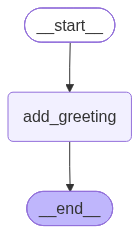

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Invoking a Graph
Runs the graph with an input by sending a state message through the entire graph

`invoke` takes a dictionary shaped like the state and returns the final state. 

Each node's return value overwrites the specified state element(s)

In [10]:
graph.invoke({"message":"Agentic AI class"})

{'message': 'Hello, Agentic AI class'}

<hr />

## 2. A sequential graph
Let's now add multiple nodes sequentially.

Construction always involves the same steps:
 - Instantiate a builder around the state
 - Add nodes
 - Add edges
 - Compile.

This is the graph we are about to build:

<img src="figures/graph_sequential.png" width="230" alt="sequential graph">

In [11]:
def add_greeting(state: State) -> dict:
    return {"message": "Hello, " + state["message"]}

def shout(state: State) -> dict:
    return {"message": state["message"].upper() + "!"}

In [13]:
from langgraph.graph import StateGraph, START, END

# construct the state graph
builder = StateGraph(State)

# add nodes
builder.add_node("add_greeting", add_greeting)
builder.add_node("shout", shout)

# add edges START -> add_greeting -> shout -> END
builder.add_edge(START, "add_greeting")
builder.add_edge("add_greeting", "shout")
builder.add_edge("shout", END)

graph = builder.compile()


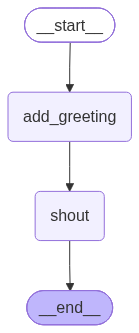

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
graph.invoke({"message": "agentic AI class"})

{'message': 'HELLO, AGENTIC AI CLASS!'}

In [16]:
for chunk in graph.stream({"message": "agentic AI class"}, stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'message': 'agentic AI class'}
Stream step state: {'message': 'Hello, agentic AI class'}
Stream step state: {'message': 'HELLO, AGENTIC AI CLASS!'}


**Notice there is no LLM anywhere yet. A graph is just orchestration; what runs inside each node is up to us.**

## 3. A chain

We'll now put a model inside the nodes. This is the **prompt chaining** pattern from the Week 1 reading (Building Effective Agents): each step's output becomes the next step's input, and the route through the graph is fixed.

<img src="figures/graph_chain.png" width="230" alt="sequential chain">

In [17]:
class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str

In [18]:
def write_joke(state: JokeState) -> dict:
    response = model.invoke(f"Write a short, clean joke about {state['topic']}.")
    return {"joke": response.text}

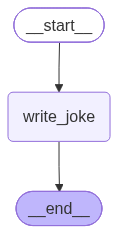

{'topic': 'college professors', 'joke': 'My college professor told me that time flies. \n\nThen he assigned a 20-page paper due tomorrow, and time decided to walk through wet concrete.'}


In [19]:
chain_builder = StateGraph(JokeState)

# add node: write_joke
chain_builder.add_node("write_joke", write_joke)

# add edges: START -> write_joke -> improve_joke -> END
chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", END)

chain = chain_builder.compile()

display(Image(chain.get_graph().draw_mermaid_png()))

result = chain.invoke({"topic": "college professors"})
print(result)

In [20]:
print(result["joke"])

My college professor told me that time flies. 

Then he assigned a 20-page paper due tomorrow, and time decided to walk through wet concrete.


One practical detail: we need to store `response.text`, not `response.content`. 

Some providers (Gemini included) return `content` as a list of content blocks rather than a plain string; `.text` always gives you the reply as a string.

In [21]:
#TODO: write the second node, improve_joke.
# It should ask the model to make state['joke'] funnier by adding a follow-up line,
# and return the result under the key 'improved_joke'.

def improve_joke(state: JokeState):
    response = model.invoke(
        "Make this joke funnier by adding a follow-up line. "
        "Return the full improved joke only.\n\n"
        f"Joke: {state['joke']}"
    )
    return {"improved_joke": response.text}


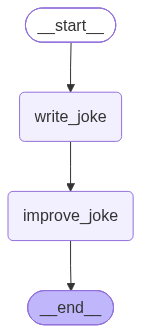

In [22]:
chain_builder = StateGraph(JokeState)

# add nodes: write_joke and improve_joke
chain_builder.add_node("write_joke", write_joke)
chain_builder.add_node("improve_joke", improve_joke)

# add edges: START -> write_joke -> improve_joke -> END
chain_builder.add_edge(START, "write_joke")
chain_builder.add_edge("write_joke", "improve_joke")
chain_builder.add_edge("improve_joke", END)

chain = chain_builder.compile()
display(Image(chain.get_graph().draw_mermaid_png()))

In [23]:
result = chain.invoke({"topic": "college professors"})

print(result["joke"])
print("---")
print(result["improved_joke"])

Why did the college professor stare at the orange juice carton for an hour?

Because the label said, "Concentrate."
---
Why did the college professor stare at the orange juice carton for an hour?

Because the label said, "Concentrate."

He finally gave up when his mind started to pulp.


In [24]:
for chunk in chain.stream({"topic": "college professors"}, stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'topic': 'college professors'}
Stream step state: {'topic': 'college professors', 'joke': 'Why do college professors love consulting a globe?\n\nIt gives them a sense of control without having to grade anything.'}
Stream step state: {'topic': 'college professors', 'joke': 'Why do college professors love consulting a globe?\n\nIt gives them a sense of control without having to grade anything.', 'improved_joke': 'Why do college professors love consulting a globe?\n\nIt gives them a sense of control without having to grade anything—plus, unlike their students, the world actually spins when you tell it to.'}


The model did the writing, but it made no decisions about control flow. The route was fixed when we drew the edges. That makes this a **workflow**, not an agent.

## 4. A router

So far every edge was fixed, with no branching/decision making. 

A **conditional edge** is used to make branching decisions. A conditional edge needs a function that inspects the state and returns the name of the node to run next.

The example: a support desk that triages incoming messages to a billing team or a general queue.

In these diagrams, solid arrows are fixed edges; **dashed red arrows are conditional edges**, where the next node is decided at runtime:

<img src="figures/graph_router.png" width="340" alt="router graph">

In [25]:
class SupportState(TypedDict):
    message: str
    reply: str

def billing(state: SupportState) -> dict:
    return {"reply": "Billing team: we will review the charge on your account."}

def general(state: SupportState) -> dict:
    return {"reply": "Support: thanks for reaching out, how can we help?"}

In [26]:
# the router function needs to return a node name
def route(state: SupportState) -> Literal["billing", "general"]:
    text = state["message"].lower()
    if any(word in text for word in ["refund", "charge", "billing", "payment"]):
        return "billing"
    return "general"

In [27]:
support_messages = [SupportState(message="I want a refund for my order"),
           SupportState(message="Do you ship to Canada?")]

In [28]:
route(support_messages[1])

'general'

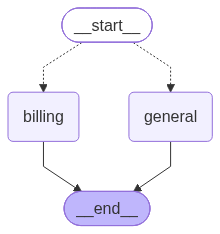

In [30]:
router_builder = StateGraph(SupportState)

router_builder.add_node("billing", billing)
router_builder.add_node("general", general)

# TODO: add the conditional edge from the start node to route
router_builder.add_conditional_edges(START, route)

router_builder.add_edge("billing", END)
router_builder.add_edge("general", END)

router = router_builder.compile()
display(Image(router.get_graph().draw_mermaid_png()))

### Adding a Fake Router Node
Not really a node because it doesn't process the state
- To the router node, add a lambda function that retuns the state as is: lambda state:state

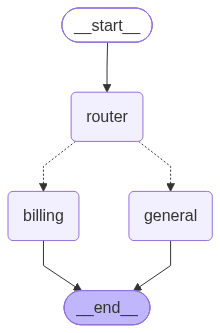

In [33]:
router_builder = StateGraph(SupportState)

router_builder.add_node("billing", billing)
router_builder.add_node("general", general)
# TODO: add the fake add node with lambda function
router_builder.add_node("router", lambda state: state)

# TODO: add the edge START -> router and conditional edge
router_builder.add_edge(START, "router")
router_builder.add_conditional_edges("router", route)

router = router_builder.compile()
display(Image(router.get_graph().draw_mermaid_png()))

In [34]:
print(router.invoke(support_messages[0])["reply"])

Billing team: we will review the charge on your account.


In [35]:
print(router.invoke(support_messages[1])["reply"])

Support: thanks for reaching out, how can we help?


The routing logic is hard-coded keywords, and keywords are brittle. "My card was hit twice for one order" is clearly a billing problem, but none of our keywords appear in it. Let the model classify instead.

In [36]:
def llm_route(state: SupportState) -> Literal["billing", "general"]:
    response = model.invoke(
        "Classify this customer message as billing or general. "
        "Answer with exactly one word: billing or general.\n\n"
        f"Message: {state['message']}"
    )
    answer = response.text.strip().lower()
    return "billing" if "billing" in answer else "general"

In [37]:
llm_route(support_messages[1])

'general'

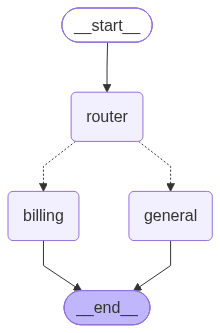

In [38]:
llm_router_builder = StateGraph(SupportState)

llm_router_builder.add_node("billing", billing)
llm_router_builder.add_node("general", general)
llm_router_builder.add_node("router", lambda state:state)

llm_router_builder.add_edge(START, "router")
llm_router_builder.add_conditional_edges("router", llm_route)
llm_router_builder.add_edge("billing", END)
llm_router_builder.add_edge("general", END)

llm_router = llm_router_builder.compile()

display(Image(llm_router.get_graph().draw_mermaid_png()))


In [39]:
print(llm_router.invoke({"message": "I have two transactions for the same order." }))

{'message': 'I have two transactions for the same order.', 'reply': 'Billing team: we will review the charge on your account.'}


In [40]:
print(llm_router.invoke({"message": "How can I return my order?" })["reply"])

Support: thanks for reaching out, how can we help?


In [41]:
for chunk in llm_router.stream(support_messages[0], stream_mode="values"):
    print("Stream step state:", chunk)

Stream step state: {'message': 'I want a refund for my order'}
Stream step state: {'message': 'I want a refund for my order'}
Stream step state: {'message': 'I want a refund for my order', 'reply': 'Billing team: we will review the charge on your account.'}


An agent needs more: decide, act, look at the result, decide again. That takes a loop in the graph, and the model's **tool calls** become the routing signal. That is what we'll cover next.